In [6]:
import os
os.chdir('..')

In [7]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import pickle
from ipywidgets import interact, FloatSlider

from agent.eval.realtime_chunking import RealtimeActionChunkingBuffer

In [8]:
chunking = pickle.load(open('debug/bedug-rca.pkl', 'rb'))
env_t0, robs = pickle.load(open('debug/bedrug-robs.pkl', 'rb'))
acts = pickle.load(open('debug/bedug-acts.pkl', 'rb'))

chunks = [d['chunk'] for d in chunking]
obs = [d['obs'] for d in chunking]
t_proc = np.array([d['t'] for d in chunking])

t_act = np.array([a[0] for a in acts])
eval_acts = np.array([a[1][0] for a in acts])

t0 = t_proc[0]
buf = RealtimeActionChunkingBuffer(1/5, weight_decay=.5)

/var/folders/pr/1v8_3tlx1rn_82tgp0zx_w1m0000gn/T/ipykernel_49805/3670437604.py:1: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  chunking = pickle.load(open('debug/bedug-rca.pkl', 'rb'))


ModuleNotFoundError: No module named 'rtde_control'

In [3]:
actions = []
ix = 0
buf._chunks = []
act_ts = t_act - t0
for t in act_ts:
    if t + t0 >= t_proc[ix]:
        buf._chunks.append(chunks[ix])
        ix += 1
    act, _ = buf.get_action(t + t0)
    actions.append(act)
actions = np.array(actions)

interactive(children=(FloatSlider(value=-0.5, description='t', max=3.5, min=-1.0, step=0.01), Output()), _dom_…

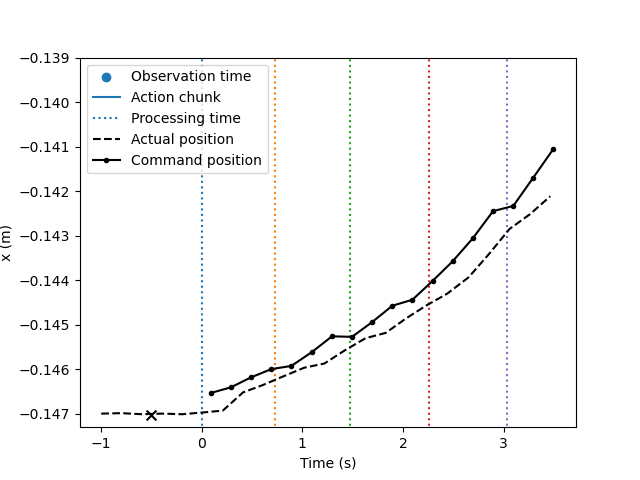

In [13]:
ix = 0
a, b = -1, 3.5

tcur = 3.5

actual = np.array([(env_t0 + ri.time - t0, ri.actual_pose[ix]) for ri in robs])
actual = actual[(a <= actual[:,0]) & (actual[:, 0] < b)]

act_sel = (a <= act_ts) & (act_ts < b)

fig, ax = plt.subplots()

scatters = []
plots = []
vlines = []
for i in range(0, 5):
    sc = ax.scatter(chunks[i].times[0] - t0, chunks[i].poses[0, ix])
    pl, = ax.plot(chunks[i].times - t0, chunks[i].poses[:, ix])
    vl = ax.vlines(t_proc[i] - t0, -1, 1, f'C{i}', linestyle='dotted')
    scatters.append(sc)
    plots.append(pl)
    vlines.append(vl)

dot = ax.scatter(actual[0, 0], actual[0, 1], marker='x', c='k', s=50, zorder=5)

pos, = ax.plot(*actual[::100].T, 'k--')
cmd, = ax.plot(act_ts[act_sel], actions[act_sel, ix], 'k.-')

ax.legend([scatters[0], plots[0], vlines[0], pos, cmd], ['Observation time', 'Action chunk', 'Processing time', 'Actual position', 'Command position'])

ax.set_xlabel('Time (s)')
ax.set_ylabel('x (m)')

ax.set_xlim(-1.21, 3.72)
ax.set_ylim(-.1473, -.139)


@interact(t=FloatSlider(min=a, max=b, value=-.5, step=0.01))
def f(t):
    tix = np.argmin(np.abs(actual[:, 0] - t))
    dot.set_offsets([actual[tix]])
    for i in range(len(scatters)):
        if t_proc[i] - t0 < t:
            scatters[i].set_visible(True)
            plots[i].set_visible(True)
        else:
            scatters[i].set_visible(False)
            plots[i].set_visible(False)
    fig.canvas.draw_idle()
